# MindQuantum 编程实践进阶：量子傅里叶变换（QFT）

## 使用 MindQuantum 实现 QFT

在 MindQuantum 中导入 QFT 线路，并以 `svg` 格式查看：

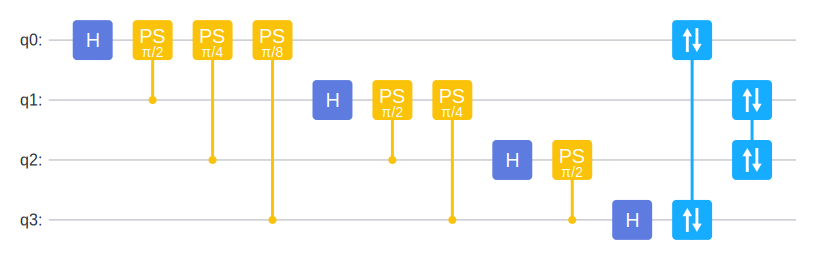

In [1]:
from mindquantum.algorithm.library import qft

circ = qft(range(4))
circ.svg()

使用量子模拟器计算 QFT 线路的末态：

In [2]:
import time
from mindquantum.simulator import Simulator
from mindquantum.algorithm.library import qft

start = time.perf_counter()
n_qubits = 8
print(f"--- 开始QFT模拟，比特数: {n_qubits} ---")

circ = qft(range(n_qubits))
sim = Simulator("mqvector", circ.n_qubits)
sim.apply_circuit(circ)
state = sim.get_qs(ket=True)

print(f"耗时: {time.perf_counter() - start:.3f}s\n")

print("\nQFT变换后的最终量子态：")
lines = state.split('\n')
print('\n'.join(lines[:16]))
print(f"... (仅显示前16项)") if len(lines) > 16 else None

--- 开始QFT模拟，比特数: 8 ---
耗时: 0.019s


QFT变换后的最终量子态：
1/16¦00000000⟩
1/16¦00000001⟩
1/16¦00000010⟩
1/16¦00000011⟩
1/16¦00000100⟩
1/16¦00000101⟩
1/16¦00000110⟩
1/16¦00000111⟩
1/16¦00001000⟩
1/16¦00001001⟩
1/16¦00001010⟩
1/16¦00001011⟩
1/16¦00001100⟩
1/16¦00001101⟩
1/16¦00001110⟩
1/16¦00001111⟩
... (仅显示前16项)


## 对比试验：使用 Numpy 实现 QFT

作为对比，我们可以尝试使用 NumPy 实现对 QFT 的模拟，看看与 MindQuantum 的实现相比有哪些差异。实现思路很直观：首先将基础量子门（H, Rk 等）定义为矩阵，然后利用张量积（kron）构建作用于整个系统的算符。

In [3]:
import time
import numpy as np
from functools import reduce

I = np.array([[1, 0], [0, 1]], dtype=np.complex128)
H = (1 / np.sqrt(2)) * np.array([[1, 1], [1, -1]], dtype=np.complex128)
X = np.array([[0, 1], [1, 0]], dtype=np.complex128)
P0 = np.array([[1, 0], [0, 0]], dtype=np.complex128)
P1 = np.array([[0, 0], [0, 1]], dtype=np.complex128)


def R(k):
    theta = 2 * np.pi / (2**k)
    return np.array([[1, 0], [0, np.exp(1j * theta)]], dtype=np.complex128)


def kron_all(ops):
    return reduce(np.kron, ops)


def apply_gate(state_vector, gate, target_qubit):
    n_qubits = int(np.log2(len(state_vector)))
    ops = [I] * n_qubits
    ops[n_qubits - 1 - target_qubit] = gate
    return kron_all(ops) @ state_vector


def apply_controlled_gate(state_vector, gate, control_qubit, target_qubit):
    n_qubits = int(np.log2(len(state_vector)))
    ops0 = [I] * n_qubits
    ops1 = [I] * n_qubits
    idx_control = n_qubits - 1 - control_qubit
    idx_target = n_qubits - 1 - target_qubit
    ops0[idx_control] = P0
    ops1[idx_control] = P1
    ops1[idx_target] = gate
    return (kron_all(ops0) + kron_all(ops1)) @ state_vector


def show_progress(step, total):
    filled = int(20 * step / total)
    bar = "#" * filled + "-" * (20 - filled)
    end = "" if step < total else "\n"
    print(f"\r量子门执行进度: [{bar}] {step}/{total}", end=end)


def qft(n_qubits):
    start = time.perf_counter()
    dim = 2**n_qubits
    state = np.zeros(dim, dtype=np.complex128)
    state[0] = 1.0
    print(f"--- 开始QFT模拟，比特数: {n_qubits} ---")
    total = n_qubits + n_qubits * (n_qubits - 1) // 2 + 3 * (n_qubits // 2)
    step = 0

    def advance():
        nonlocal step
        step += 1
        show_progress(step, total)

    for i in range(n_qubits):
        state = apply_gate(state, H, i)
        advance()
        for j in range(i + 1, n_qubits):
            state = apply_controlled_gate(state, R(j - i + 1), j, i)
            advance()
    for i in range(n_qubits // 2):
        j = n_qubits - 1 - i
        for control, target in ((i, j), (j, i), (i, j)):
            state = apply_controlled_gate(state, X, control, target)
            advance()
    print(f"耗时: {time.perf_counter() - start:.3f}s")
    return state


n_qubits = 8
final_state = qft(n_qubits)
print("\nQFT变换后的最终量子态：")
for i, amp in enumerate(final_state[:16]):
    print(f"|{bin(i)[2:].zfill(n_qubits)}> :  振幅 = {amp:+.3f}")
print(f"... (仅显示前16项)") if len(final_state) > 16 else None

--- 开始QFT模拟，比特数: 8 ---
量子门执行进度: [####################] 48/48
耗时: 0.161s

QFT变换后的最终量子态：
|00000000> :  振幅 = +0.062+0.000j
|00000001> :  振幅 = +0.062+0.000j
|00000010> :  振幅 = +0.062+0.000j
|00000011> :  振幅 = +0.062+0.000j
|00000100> :  振幅 = +0.062+0.000j
|00000101> :  振幅 = +0.062+0.000j
|00000110> :  振幅 = +0.062+0.000j
|00000111> :  振幅 = +0.062+0.000j
|00001000> :  振幅 = +0.062+0.000j
|00001001> :  振幅 = +0.062+0.000j
|00001010> :  振幅 = +0.062+0.000j
|00001011> :  振幅 = +0.062+0.000j
|00001100> :  振幅 = +0.062+0.000j
|00001101> :  振幅 = +0.062+0.000j
|00001110> :  振幅 = +0.062+0.000j
|00001111> :  振幅 = +0.062+0.000j
... (仅显示前16项)


> 可以更改量子线路的比特数 `n_qubits` ，观察不同比特规模下的运行耗时。（Numpy的部分不要超过12比特，内存占用会飙升）

可以看到，基于 Numpy 的实现与基于 MindQuantum 的实现相比：

- 使用 Numpy 手工构建需要从头实现量子计算模拟过程，代码量较大；
- 性能上则差异更加明显：随着比特数的增加，基于 Numpy 的实现会比基于 MindQuantum 的实现慢上百倍甚至上万倍；
- 如果观察内存占用情况，会发现基于 Numpy 的实现会占用巨量内存，12比特就达到 GB 级别，而 MindQuantum 在个人PC上可以模拟到28比特左右的规模。

# 编程实践：量子近似优化算法

运行以下代码需要安装networkx和mindspore，可运行：

    %pip install networkx

    %pip install mindspore

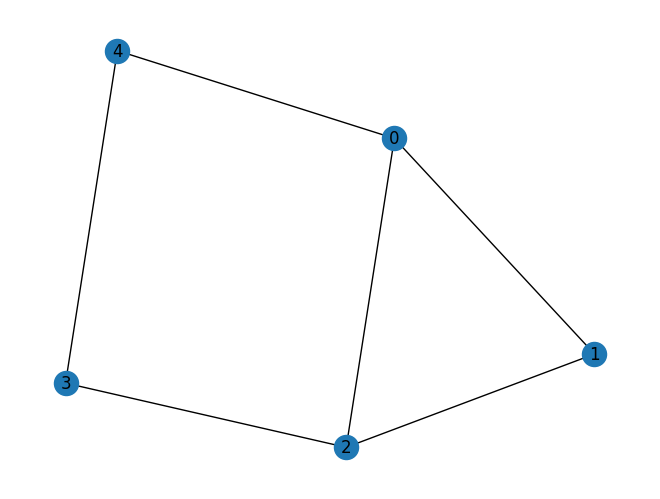

In [4]:
from mindquantum.algorithm import MaxCutAnsatz
from mindquantum.core.operators import Hamiltonian, QubitOperator
from mindquantum.framework import MQAnsatzOnlyLayer
import networkx as nx
import mindspore.nn as nn

# 构造待求解图
graph = nx.Graph([(0, 1), (1, 2), (2, 3), (3, 4), (0, 4), (0, 2)])
nx.draw(graph, with_labels=True)

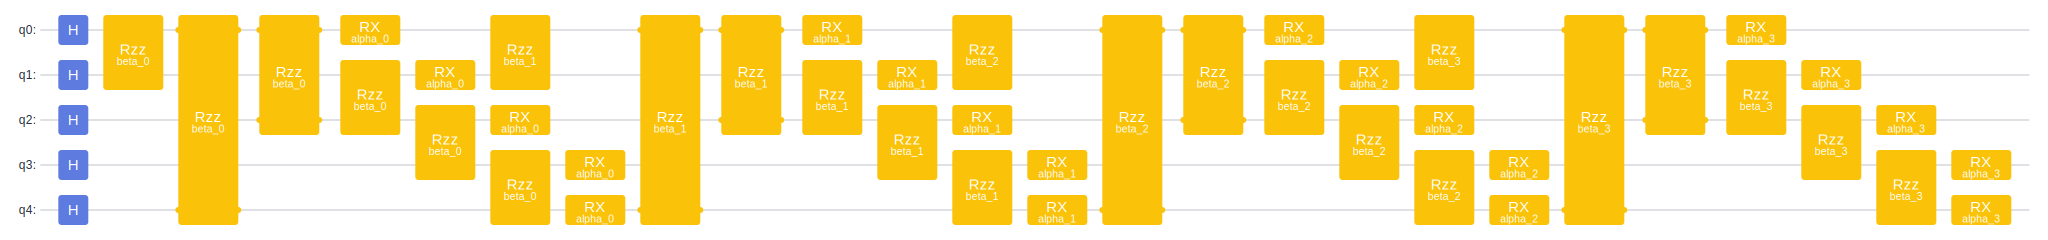

In [5]:
# 将图转化为目标哈密顿量
pauli_ops = QubitOperator()
for i in graph.edges:
    pauli_ops += QubitOperator(f'Z{i[0]} Z{i[1]}')
ham = Hamiltonian(pauli_ops)

# 构造线路
circ = MaxCutAnsatz(list(graph.edges), depth=4).circuit
circ.svg()

In [6]:
# 创建模拟器，backend使用‘mqvector’，能模拟5个比特（'circ'线路中包含的比特数）
sim = Simulator("mqvector", 5)

# 生成计算变分量子线路的期望值和梯度的算子
grad_ops = sim.get_expectation_with_grad(ham, circ)

# 生成待训练的神经网络
net = MQAnsatzOnlyLayer(grad_ops)

# 设置针对网络中所有可训练参数、学习率为0.05的Adam优化器
opti = nn.Adam(net.trainable_params(), learning_rate=0.05)

# 生成能对神经网络进行一步训练的算子
train_net = nn.TrainOneStepCell(net, opti)

for i in range(200):

    # 将神经网络训练一步并计算得到的结果（切割边数）。注意：每当'train_net()'运行一次，神经网络就训练了一步
    cut = (len(graph.edges) - train_net()) / 2

    # 每训练10步，打印当前训练步数和当前得到的切割边数
    if i % 10 == 0:
        print("train step:", i, ", cut:", cut)

train step: 0 , cut: [2.999792]
train step: 10 , cut: [4.2779665]
train step: 20 , cut: [4.652581]
train step: 30 , cut: [4.7771645]
train step: 40 , cut: [4.832399]
train step: 50 , cut: [4.8645806]
train step: 60 , cut: [4.8773127]
train step: 70 , cut: [4.8974237]
train step: 80 , cut: [4.919452]
train step: 90 , cut: [4.9362864]
train step: 100 , cut: [4.9383116]
train step: 110 , cut: [4.938368]
train step: 120 , cut: [4.9392333]
train step: 130 , cut: [4.9391537]
train step: 140 , cut: [4.9392347]
train step: 150 , cut: [4.9392524]
train step: 160 , cut: [4.939253]
train step: 170 , cut: [4.9392567]
train step: 180 , cut: [4.9392567]
train step: 190 , cut: [4.939257]


# 作业2：使用VQE算法计算氢分子的势能曲线

在本作业中，我们将使用变分量子本征求解器(VQE)算法来计算氢分子的势能曲线。具体步骤：

1. 使用给定的`get_H2_ham()`函数，根据不同的键长生成氢分子的哈密顿量。
2. 构建如下图所示的量子线路，并优化其参数以最小化哈密顿量的期望值。
3. 通过遍历不同的键长(0.5-1.1埃米)，计算对应的基态能量，绘制势能曲线。
4. 将VQE计算结果与完全组态相互作用(FCI)和Hartree-Fock(HF)方法的结果进行对比。

势能曲线展示了氢分子的基态能量如何随着两个氢原子间距离变化。曲线的最低点对应平衡键长，此时分子最稳定。当原子距离偏离平衡位置时，能量会升高：距离过小时由于核间排斥能量升高，距离过大时分子趋向解离。通过分析势能曲线，我们可以研究分子的稳定性、结合能和平衡构型等重要性质。

在这里，我们将VQE的结果与两种经典计算方法进行对比：
- 完全组态相互作用(FCI)方法：这是一种精确的量子化学计算方法，考虑了所有可能的电子组态，能得到最准确的结果，但计算成本随系统大小呈指数增长。FCI的结果将作为我们的参考标准。
- Hartree-Fock(HF)方法：这是一种近似方法，通过平均场近似来处理电子间的相互作用。HF方法计算速度快，但准确度较低，特别是在描述强关联体系时。

**请在标记为`#TODO`的位置完成代码编写，并将包裹代码的多行注释符`""" """`删除。每个TODO位置需要根据注释说明实现相应功能。**

> 注意： 需要用到的`openfermion`和`openfermionpyscf`库仅支持Linux和MacOS，如果没有合适的环境，可以尝试使用[Mybinder临时环境](https://mybinder.org/v2/gh/MindQuantum-HiQ/mq-env/HEAD)或[CodeArts IDE 提供的环境](https://www.hiascend.com/forum/thread-0286153651461045030-1-1.html)。

> 如果使用**Mybinder临时环境**，需要注意**及时下载保存修改**。该环境如果超过 **10 分钟**没有操作就会自动关闭，并且内容全部重置，**修改会全部丢失！**

<img src="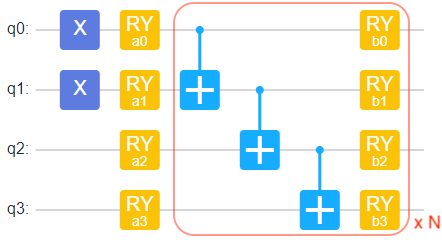
" width="400"/>

*Hartree-Fork + Hardware Efficient Ansatz*

运行以下代码前需要安装openfermionpyscf，可运行

    %pip install openfermionpyscf

构建的量子线路:
      ┏━━━┓ ┏━━━━━━━━┓       ┏━━━━━━━━━━┓             ┏━━━━━━━━━━┓                     
q0: ──┨╺╋╸┠─┨ RY(a0) ┠───■───┨ RY(b0_0) ┠─────────■───┨ RY(b1_0) ┠─────────■─────────[red bold]↯[/]─
      ┗━━━┛ ┗━━━━━━━━┛   ┃   ┗━━━━━━━━━━┛         ┃   ┗━━━━━━━━━━┛         ┃           
      ┏━━━┓ ┏━━━━━━━━┓ ┏━┻━┓       ┏━━━━━━━━━━┓ ┏━┻━┓       ┏━━━━━━━━━━┓ ┏━┻━┓         
q1: ──┨╺╋╸┠─┨ RY(a1) ┠─┨╺╋╸┠───■───┨ RY(b0_1) ┠─┨╺╋╸┠───■───┨ RY(b1_1) ┠─┨╺╋╸┠───■───[red bold]↯[/]─
      ┗━━━┛ ┗━━━━━━━━┛ ┗━━━┛   ┃   ┗━━━━━━━━━━┛ ┗━━━┛   ┃   ┗━━━━━━━━━━┛ ┗━━━┛   ┃     
      ┏━━━━━━━━┓             ┏━┻━┓       ┏━━━━━━━━━━┓ ┏━┻━┓       ┏━━━━━━━━━━┓ ┏━┻━┓   
q2: ──┨ RY(a2) ┠─────────────┨╺╋╸┠───■───┨ RY(b0_2) ┠─┨╺╋╸┠───■───┨ RY(b1_2) ┠─┨╺╋╸┠─[red bold]↯[/]─
      ┗━━━━━━━━┛             ┗━━━┛   ┃   ┗━━━━━━━━━━┛ ┗━━━┛   ┃   ┗━━━━━━━━━━┛ ┗━━━┛   
      ┏━━━━━━━━┓                   ┏━┻━┓ ┏━━━━━━━━━━┓       ┏━┻━┓ ┏━━━━━━━━━━┓         
q3: ──┨ RY(a3) ┠───────────────────┨╺╋╸┠─┨ RY(b0_3) ┠───────┨╺╋╸┠─┨ RY(b

[WARNING] ME(238,718a5be46440,python):2026-01-01-09:29:54.522.074 [mindspore/ccsrc/tools/error_handler/error_config.cc:215] operator()] Value of `MS_ENABLE_TFT` is ``
[WARNING] ME(238,718a5be46440,python):2026-01-01-09:29:54.522.113 [mindspore/ccsrc/tools/error_handler/error_config.cc:163] operator()] Can find `TRE` in environment var `MS_ENABLE_TFT`


  迭代   0, 损失: -1.044333, 能量: -1.044229, 与FCI误差: 0.010931
  迭代 100, 损失: -1.055160, 能量: -1.055160, 与FCI误差: 0.000000
  迭代 200, 损失: -1.055160, 能量: -1.055160, 与FCI误差: 0.000000
  迭代 300, 损失: -1.055160, 能量: -1.055160, 与FCI误差: 0.000000
  迭代 400, 损失: -1.055160, 能量: -1.055160, 与FCI误差: 0.000000
  最佳VQE能量: -1.055160, FCI能量: -1.055160, 误差: 0.000000

正在计算键长 d = 0.55 Å 的能量...
  迭代   0, 损失: -1.078549, 能量: -1.079008, 与FCI误差: 0.013622
  迭代 100, 损失: -1.092630, 能量: -1.092630, 与FCI误差: 0.000000
  迭代 200, 损失: -1.092630, 能量: -1.092630, 与FCI误差: 0.000000
  迭代 300, 损失: -1.092630, 能量: -1.092630, 与FCI误差: 0.000000
  迭代 400, 损失: -1.092630, 能量: -1.092630, 与FCI误差: 0.000000
  最佳VQE能量: -1.092630, FCI能量: -1.092630, 误差: 0.000000

正在计算键长 d = 0.60 Å 的能量...
  迭代   0, 损失: -1.100852, 能量: -1.100167, 与FCI误差: 0.016119
  迭代 100, 损失: -1.116286, 能量: -1.116286, 与FCI误差: 0.000000
  迭代 200, 损失: -1.116286, 能量: -1.116286, 与FCI误差: 0.000000
  迭代 300, 损失: -1.116286, 能量: -1.116286, 与FCI误差: 0.000000
  迭代 400, 损失: -1.116286, 能量: -1.116286, 与FCI

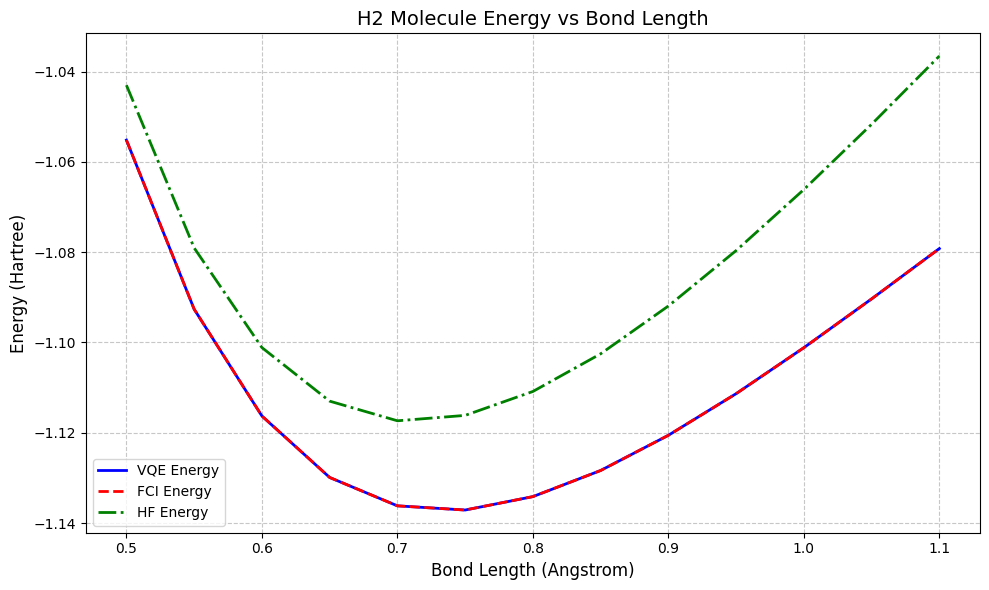

Abs(VQE - FCI): [1.2734573617834144e-08, 2.7702737881440953e-09, 3.2482876610728795e-08, 3.731363640291363e-08, 6.688471554383568e-09, 3.910934243123165e-08, 2.2634125684817263e-08, 5.7283490395576564e-08, 7.129271617500876e-09, 3.214635713177927e-08, 5.595588525864059e-08, 1.2473150956537893e-08, 5.1056010752503767e-08]

VQE计算结果统计

VQE与FCI误差统计:
  平均绝对误差: 0.000000 Hartree
  最大绝对误差: 0.000000 Hartree
  最小绝对误差: 0.000000 Hartree

平衡键长:
  VQE: 0.75 Å, 能量: -1.137117 Hartree
  FCI: 0.75 Å, 能量: -1.137117 Hartree

重合度分析:
  误差小于 0.0005 Hartree 的数据点: 13/13
  ✓ 所有数据点VQE能量与FCI能量在 0.0005 Hartree 阈值内重合良好！


In [1]:
from openfermion.chem import MolecularData
from openfermionpyscf import run_pyscf
from mindquantum.core.operators import Hamiltonian
from mindquantum.algorithm import get_qubit_hamiltonian
from mindquantum.core.gates import X, RY
from mindquantum.core.circuit import Circuit
from mindquantum.simulator import Simulator
from mindquantum.framework import MQAnsatzOnlyLayer
import mindspore.nn as nn
from matplotlib import pyplot as plt
import numpy as np


def get_H2_ham(d):
    """
    根据键长生成H2分子哈密顿量
    Args:
        d (float): 键长，单位埃米
    Returns:
        Hamiltonian: H2分子哈密顿量
    """
    mol = MolecularData([("H", (0, 0, 0)), ("H", (0, 0, d))], "sto3g", multiplicity=1)
    mol = run_pyscf(mol, run_fci=1)
    return Hamiltonian(get_qubit_hamiltonian(mol)), mol.fci_energy, mol.hf_energy


# TODO: 请根据图中所示构建量子线路
circ = Circuit()

# 初始状态准备：在q0和q1上施加X门
circ += X.on(0)  # q0
circ += X.on(1)  # q1

# 第一层RY门：所有4个量子比特上都有RY门，参数分别为a0, a1, a2, a3
circ += RY('a0').on(0)  # q0
circ += RY('a1').on(1)  # q1
circ += RY('a2').on(2)  # q2
circ += RY('a3').on(3)  # q3

# 三个受控门（CNOT门）
circ += X.on(1, 0)  # 控制比特是q0，目标比特是q1
circ += X.on(2, 1)  # 控制比特是q1，目标比特是q2
circ += X.on(3, 2)  # 控制比特是q2，目标比特是q3

# 重复结构：标记为"x N"，N=3
N = 3  # 增加重复次数以提高精度
for i in range(N):
    # RY门层，参数分别为b0, b1, b2, b3
    circ += RY(f'b{i}_0').on(0)  # q0
    circ += RY(f'b{i}_1').on(1)  # q1
    circ += RY(f'b{i}_2').on(2)  # q2
    circ += RY(f'b{i}_3').on(3)  # q3
    
    # 三个受控门（CNOT门）
    circ += X.on(1, 0)  # 控制比特是q0，目标比特是q1
    circ += X.on(2, 1)  # 控制比特是q1，目标比特是q2
    circ += X.on(3, 2)  # 控制比特是q2，目标比特是q3

print("构建的量子线路:")
print(circ)
print(f"线路深度: {circ.depth()}")
print(f"参数数量: {len(circ.params_name)}")

# Initialize lists to store results
distances = [i/20 for i in range(10, 23)]  # From 0.5 to 1.1 Angstrom with 0.05 step
energies = []
fci_energies = []
hf_energies = []

# Create simulator
sim = Simulator('mqvector', 4)

# 训练参数 - 增加迭代次数以提高精度
num_iterations = 500

for d in distances:
    # Calculate Hamiltonian for current distance
    ham, fci_energy, hf_energy = get_H2_ham(d)

    fci_energies.append(fci_energy)
    hf_energies.append(hf_energy)

    # TODO: 获取期望值和梯度算子
    grad_ops = sim.get_expectation_with_grad(ham, circ)

    # TODO: 生成待训练的神经网络
    net = MQAnsatzOnlyLayer(grad_ops)
    
    # TODO: 设置优化器 - 使用较小的学习率以获得更好的收敛
    optimizer = nn.Adam(net.trainable_params(), learning_rate=0.03)
    
    # TODO: 生成能对神经网络进行一步训练的算子
    train_net = nn.TrainOneStepCell(net, optimizer)

    # 对网络进行训练
    print(f"\n正在计算键长 d = {d:.2f} Å 的能量...")
    
    # 跟踪最佳能量
    best_energy = float('inf')
    
    for i in range(num_iterations):
        loss = train_net()
        
        # 提取损失值
        loss_value = loss.asnumpy()
        if isinstance(loss_value, np.ndarray):
            loss_value = loss_value[0] if loss_value.size > 0 else 0
        
        # 获取当前能量
        current_energy = net().asnumpy()
        if isinstance(current_energy, np.ndarray):
            current_energy = current_energy[0] if current_energy.size > 0 else 0
        
        # 更新最佳能量
        if current_energy < best_energy:
            best_energy = current_energy
        
        # 可选：打印训练进度
        if i % 100 == 0:
            print(f'  迭代 {i:3d}, 损失: {loss_value:.6f}, 能量: {current_energy:.6f}, 与FCI误差: {abs(current_energy - fci_energy):.6f}')

    # 使用最佳能量
    energies.append(best_energy)
    print(f'  最佳VQE能量: {best_energy:.6f}, FCI能量: {fci_energy:.6f}, 误差: {abs(best_energy - fci_energy):.6f}')

# Plot results
plt.figure(figsize=(10, 6))
if energies:
    plt.plot(distances, energies, 'b-', label='VQE Energy', linewidth=2)
plt.plot(distances, fci_energies, 'r--', label='FCI Energy', linewidth=2)
plt.plot(distances, hf_energies, 'g-.', label='HF Energy', linewidth=2)
plt.xlabel('Bond Length (Angstrom)', fontsize=12)
plt.ylabel('Energy (Hartree)', fontsize=12)
plt.title('H2 Molecule Energy vs Bond Length', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

diffs = [abs(e - f) for e, f in zip(energies, fci_energies)]
print("Abs(VQE - FCI):", diffs)

# 计算并打印统计信息
if energies:
    print("\n" + "="*60)
    print("VQE计算结果统计")
    print("="*60)
    
    # VQE与FCI的误差
    vqe_fci_diffs = [abs(e - f) for e, f in zip(energies, fci_energies)]
    
    print(f"\nVQE与FCI误差统计:")
    print(f"  平均绝对误差: {np.mean(vqe_fci_diffs):.6f} Hartree")
    print(f"  最大绝对误差: {np.max(vqe_fci_diffs):.6f} Hartree")
    print(f"  最小绝对误差: {np.min(vqe_fci_diffs):.6f} Hartree")
    
    # 找到平衡键长（能量最低点）
    min_vqe_idx = np.argmin(energies)
    min_fci_idx = np.argmin(fci_energies)
    
    print(f"\n平衡键长:")
    print(f"  VQE: {distances[min_vqe_idx]:.2f} Å, 能量: {energies[min_vqe_idx]:.6f} Hartree")
    print(f"  FCI: {distances[min_fci_idx]:.2f} Å, 能量: {fci_energies[min_fci_idx]:.6f} Hartree")
    
    # 检查VQE和FCI是否重合良好
    threshold = 0.0005  # 0.5 mHartree的阈值
    good_fit_count = sum(1 for diff in vqe_fci_diffs if diff < threshold)
    
    print(f"\n重合度分析:")
    print(f"  误差小于 {threshold} Hartree 的数据点: {good_fit_count}/{len(vqe_fci_diffs)}")
    
    if good_fit_count == len(vqe_fci_diffs):
        print(f"  ✓ 所有数据点VQE能量与FCI能量在 {threshold} Hartree 阈值内重合良好！")
    else:
        print(f"  ✗ VQE能量与FCI能量未能在所有数据点上达到 {threshold} Hartree 阈值内的重合。")



# 作业3：挑战题——破解神秘量子门的相位（量子相位估计）

## 题目背景

假设你获得了一个神秘的单比特量子门 $U$（代码中封装为 `MysteryGate`），它的作用效果是：
$$ U|1\rangle = e^{2\pi i \varphi} |1\rangle $$
你的任务是利用 **量子相位估计算法 (QPE)**，找出这个神秘相位 $\varphi$ 的值（一个 $0$ 到 $1$ 之间的小数）。

## 任务要求

你需要构建一个标准的 QPE 线路，它包含三个步骤：
1.  **叠加 (Superposition)**：对用于估计的辅助比特施加 Hadamard 门，将目标比特翻转到 $|1\rangle$ 态。
2.  **受控幺正演化 (Controlled-U)**：对第 $i$ 个辅助比特，施加受控的 $U^{2^i}$ 操作。
3.  **逆量子傅里叶变换 (Inverse QFT)**：将相位信息转化为可测量的基态信息，并通过测量反推出 $\varphi$。

![QPE Circuit](https://mindspore-website.obs.cn-north-4.myhuaweicloud.com/website-images/r2.7.0rc1/docs/mindquantum/docs/source_zh_cn/images/quantum_phase_estimation.png)
（注：本题中 $U$ 作用在最后一个量子比特上，辅助比特为前 $n$ 个）

## 关键接口说明

1. 量子门的指数形式

    在MindQuantum中，实现 $U^{n}$ 及其受控操作非常简单：
    * **`Power(Gate, exponent)`**：返回量子门的指数形式。例如 `Power(U, 4)` 等价于 $U^4$。
    * **`.on(target, control)`**：指定目标比特和控制比特。
    * **示例**：`Power(U, n).on(i, j)` 表示以第 `j` 号比特为控制，第 `i` 号比特为目标，执行 $U^{n}$ 操作。

2. 逆量子傅里叶变换

    `qft(qubits)` 函数会生成指定比特上的量子傅里叶变换（QFT）线路。由于 QPE 需要用到 QFT 的逆操作（$QFT^\dagger$），你需要调用 `.hermitian()` 方法来获取其共轭转置线路。例如：`qft(range(4)).hermitian()`。

**请在标记为`#TODO`的位置完成代码编写，并将包裹代码的多行注释符`""" """`删除。**


In [4]:
'''
import numpy as np
from mindquantum.core.circuit import Circuit, UN
from mindquantum.core.gates import H, X, Power, PhaseShift, BARRIER, Measure
from mindquantum.simulator import Simulator
from mindquantum.algorithm.library import qft

# 1. 准备神秘门
true_phi = 0.625
MysteryGate = PhaseShift(2 * np.pi * true_phi)

# 2. 构建 QPE 线路

# TODO

# 3. 模拟与测量

# TODO
# result =


"""

# 4. 解析结果
# 获取出现概率最高的二进制串 (例如 '1010')
bit_string = list(result.data.keys())[0]

# QPE线路示意图中采用大端序，MinsQuantum采用的则是小端序，因此需要反转比特串顺序。
bit_string = bit_string[::-1]

# 计算估计相位: int(二进制串, 2) / 2^n
estimated_phi = int(bit_string, 2) / (2**n_qubits)

print(f"测量结果: {bit_string}")
print(f"估计相位: {estimated_phi}")

if abs(estimated_phi - true_phi) < 1e-5:
    print("🎉 恭喜！你成功破解了神秘相位！")
else:
    print("结果有误差，请检查受控门的顺序或QFT范围。")

"""

'''

import numpy as np
from mindquantum.core.circuit import Circuit, UN
from mindquantum.core.gates import H, X, Power, PhaseShift, BARRIER, Measure
from mindquantum.simulator import Simulator
from mindquantum.algorithm.library import qft

# 1. 准备神秘门
true_phi = 0.625
MysteryGate = PhaseShift(2 * np.pi * true_phi)

# 2. 构建 QPE 线路
# 根据电路图，设置辅助比特数量
n_aux = 4  # 辅助比特数量，对应图中的 t 个量子比特
n_total = n_aux + 1  # 总比特数（辅助比特 + 目标比特）

# 初始化线路
circ = Circuit()

# 步骤1：初始化
# 第一寄存器（辅助比特）：全部初始化为 |0⟩，然后应用 Hadamard 门
for i in range(n_aux):
    circ += H.on(i)

# 第二寄存器（目标比特）：初始化为 |u⟩ = |1⟩（因为只有|1⟩态才有相位变化）
# 注意：根据电路图，目标比特是最后一个比特
target_qubit = n_aux
circ += X.on(target_qubit)

circ += BARRIER

# 步骤2：受控幺正演化（Controlled-U 操作）
# 根据电路图，第一个辅助比特（最上面的）对应最高有效位
# 在MindQuantum中，我们需要将指数对应到正确的比特
for i in range(n_aux):
    # 电路图中，第j个辅助比特控制 U^(2^(t-1-j)) 操作
    # 其中j=0是最上面的比特（最高有效位）
    # 实际上，对于QPE，第i个辅助比特应该控制U^(2^i)操作
    # 但我们需要考虑比特顺序
    power = 2**i  # 修正：标准QPE中，第i个辅助比特控制U^(2^i)
    control_qubit = i
    # 应用受控门：控制比特为control_qubit，目标比特为target_qubit
    circ += Power(MysteryGate, power).on(target_qubit, control_qubit)

circ += BARRIER

# 步骤3：逆量子傅里叶变换
# 对辅助比特应用逆QFT
# 注意：根据电路图，QFT应用在第一寄存器（辅助比特）上
circ += qft(range(n_aux)).hermitian()

# 步骤4：测量
# 测量所有辅助比特
for i in range(n_aux):
    circ += Measure(f'q{i}').on(i)

# 3. 模拟与测量
# 创建模拟器，使用默认后端（通常是'mqvector'）
sim = Simulator('mqvector', n_total)

# 演化线路并测量
result = sim.sampling(circ, shots=1000)

# 4. 解析结果
# 获取出现概率最高的二进制串
bit_string = list(result.data.keys())[0]

# 在QPE中，测量结果表示相位的二进制近似
# 电路图采用大端序（最高有效位对应第一个辅助比特）
# MindQuantum采用小端序，因此需要反转比特串顺序
bit_string = bit_string[::-1]

# 计算估计相位: int(二进制串, 2) / 2^n
estimated_phi = int(bit_string, 2) / (2**n_aux)

print(f"真实相位: {true_phi}")
print(f"测量结果: {bit_string}")
print(f"估计相位: {estimated_phi}")

# 验证结果
if abs(estimated_phi - true_phi) < 1e-5:
    print("🎉 恭喜！你成功破解了神秘相位！")
else:
    # 计算误差
    error = abs(estimated_phi - true_phi)
    print(f"结果有误差: {error}")
    # 对于4个辅助比特，精度为1/16=0.0625
    print(f"使用{n_aux}个辅助比特的理论精度: {1/(2**n_aux)}")

# 可选：打印电路结构查看
print("\n量子线路结构:")
print(circ)

# 可选：查看详细的测量结果分布
print("\n测量结果分布（前5个）:")
sorted_results = sorted(result.data.items(), key=lambda x: x[1], reverse=True)
for i, (bits, count) in enumerate(sorted_results[:5]):
    print(f"  {bits[::-1]}: {count}次")


真实相位: 0.625
测量结果: 0100
估计相位: 0.25
结果有误差: 0.375
使用4个辅助比特的理论精度: 0.0625

量子线路结构:
      ┏━━━┓                                                                          
q0: ──┨ H ┠────────■──────────────────────────────────────────────────────╳───────[red bold]↯[/]─ 
      ┗━━━┛        ┃                                                      ┃          
      ┏━━━┓        ┃                                                      ┃          
q1: ──┨ H ┠────────╂──────────────■─────────────────────────────────────╳─┃───────[red bold]↯[/]─ 
      ┗━━━┛        ┃              ┃                                     ┃ ┃          
      ┏━━━┓        ┃              ┃                                     ┃ ┃          
q2: ──┨ H ┠────────╂──────────────╂──────────────■──────────────────────╳─┃───────[red bold]↯[/]─ 
      ┗━━━┛        ┃              ┃              ┃                        ┃          
      ┏━━━┓        ┃              ┃              ┃                        ┃ ┏━━━┓    
q3: ──┨ H ┠────────╂───